# Linking SCE utility data with building polygons
This notebook will take Global Building Atlas polygons and link to the nearest SCE feeder line.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt
import glob
import os
import folium

In [2]:
pd.set_option('display.max_columns', None)

# 1. SCE Circuit Segments

In [5]:
sce_circ_segments = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sce_circuits/ICA_-_Circuit_Segments.geojson")

In the final exported dataframe, we will select columns to keep.

# Columns of Interest

**From Global Building Atlas**:

- id
- height

**From SCE Circuit Segments/Customer Info**:

- circuit_name
- section_id/node_id (in the vocab dictionary these are defined as the same thing)
- substation_name
- ica_overall_load
- ica_overall_pv_op_flex
- ica_overall_pv
- uniform_generation
- uniform_generation_op_flex
- res_pct
- com_pct
- agr_pct
- other_pct
- dist_to_line_m

For one circuit, we must check if there are different values of ICA capacity at different segments.

In [4]:
# Convert overall load column to float
sce_circ_segments['ica_overall_load'] = sce_circ_segments['ica_overall_load'].astype(float)
sce_circ_segments['section_id'] = sce_circ_segments['section_id'].astype(str)

In [36]:
# Filter to one circuit
test_circuit = sce_circ_segments[sce_circ_segments['circuit_name'] == 'Parafine']

<Axes: >

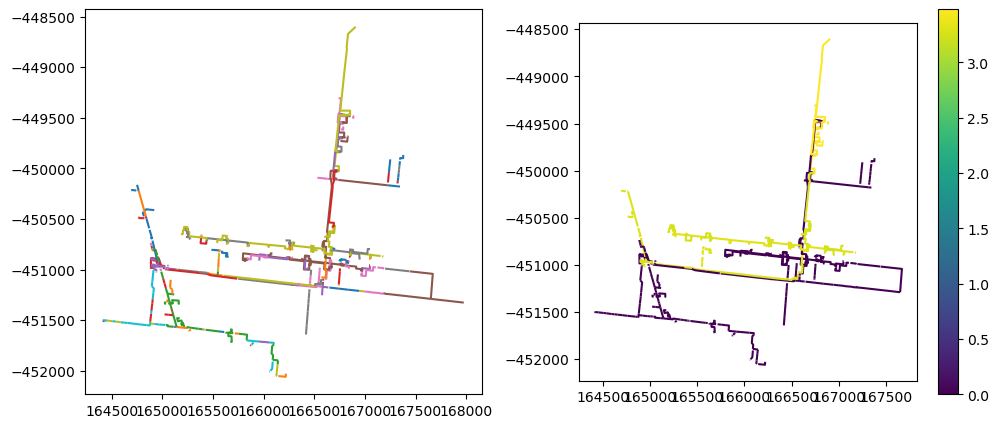

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

test_circuit.plot(ax=axes[0], column='section_id')
test_circuit.plot(ax=axes[1], column='ica_overall_load', legend=True)

In [7]:
print(test_circuit['ica_overall_load'].unique())

[0.   3.25 3.29 3.3  3.24 3.26 3.31 3.48 3.32  nan 3.27]


In [8]:
sce_circ_segments.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
# Convert to projected crs
sce_circ_segments = sce_circ_segments.to_crs(epsg=3310)

# 1a. SCE Customer Table

Retrieved from: [ICA Tables Layer](https://drpep-sce2.opendata.arcgis.com/maps/f76174d459a14545b2b13110d1cc6fba/about). This table contains data for customer type (residential, commercial, agricultural) on each SCE circuit and will be joined to SCE ICA data by `circuit_name`.

In [9]:
sce_table = pd.read_csv("../../../../capstone/electrigrid/data/utilities/sce_circuits/ICA_Single_Consolidated_Table.csv")

,circuit_name,circuit_id,circuit_voltage,percent_15_cap,res_pct,com_pct,agr_pct,other_pct,ind_pct,sub_name,subst_id,note_sub,layer_identifier,sys_name,existing_gen,queued_gen,total_gen,projected_load,penetration_level,max_remain_cap,agr_total,com_total,ind_total,res_total,other_total,OBJECTID
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jose,1060.0,Interconnection studies in this area have iden...,ESRI_DRP_SUBSTATION_T_DRP,Rio Hondo 220/66 System,0.0,0.0,0.0,5.00,0.0,5.0,NaN,NaN,NaN,NaN,NaN,1
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Julian Hinds,235.0,Interconnection studies in this area have iden...,ESRI_DRP_SUBSTATION_T_DRP,Mwd 220/220 System,0.0,0.0,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,2
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Glow,2172.0,Interconnection studies in this area have iden...,ESRI_DRP_SUBSTATION_T_DRP,Antelope 220/66 System,0.0,0.0,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,3
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Growers,2280.0,Interconnection studies in this area have iden...,ESRI_DRP_SUBSTATION_T_DRP,Vestal 220/66 System,0.0,0.0,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,4
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Haagen,1149.0,Interconnection studies in this area have iden...,ESRI_DRP_SUBSTATION_T_DRP,Rector 220/66 System,0.0,0.0,0.0,4.79,0.0,5.6,NaN,NaN,NaN,NaN,NaN,5


In [ ]:
# drop na rows in circuit_name columns
sce_table = sce_table.dropna(subset=['circuit_name'])
sce_table.head()

,circuit_name,circuit_id,circuit_voltage,percent_15_cap,res_pct,com_pct,agr_pct,other_pct,ind_pct,sub_name,subst_id,note_sub,layer_identifier,sys_name,existing_gen,queued_gen,total_gen,projected_load,penetration_level,max_remain_cap,agr_total,com_total,ind_total,res_total,other_total,OBJECTID
1286,Abacus,2131371.0,12.0,0.0,76.59,7.60,0.00,15.81,0.00,Highland,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,San Bernardino 220/66 System,2.272,2.344,4.615,8.26,55.86,5.38,0.0,62.0,0.0,625.0,129.0,1287
1287,Abana,2104017.0,12.0,1.0,13.85,62.31,0.00,23.08,0.77,Greening,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Del Amo 220/66 System,0.423,0.017,0.440,9.58,4.59,9.56,0.0,81.0,1.0,18.0,30.0,1288
1288,Abbey,2104018.0,12.0,0.0,43.39,4.24,12.72,39.65,0.00,Bliss,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Springville 220/66 System,0.347,3.151,3.498,3.80,91.93,6.50,51.0,17.0,0.0,174.0,159.0,1289
1289,Abbot,2140851.0,12.0,0.0,72.22,17.80,0.00,9.99,0.00,Ellis,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Ellis 220/66 System,1.185,0.065,1.250,7.82,15.98,8.75,0.0,139.0,0.0,564.0,78.0,1290
1290,Aberdeen,2140852.0,12.0,0.0,71.43,12.83,0.00,15.74,0.00,Bovine,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Del Amo 220/66 System,0.996,0.062,1.058,6.25,16.91,8.94,0.0,53.0,0.0,295.0,65.0,1291


In [ ]:
# join ica & table data by circuit name
sce_segments_table = pd.merge(left=sce_circ_segments, right=sce_table, how='left', on='circuit_name')
sce_segments_table.head()

,download_link_microgrid,changed_date,lgp_flag,most_limiting_factor,circuit_name,section_id,node_id,phase,circuit_voltage_x,substation_name,substation_voltage,system_name,ica_overall_load,ica_overall_pv_op_flex,ica_overall_pv,uniform_generation_op_flex,uniform_generation,note,download_link,disclaimer,objectid,Shape__Length,geometry,circuit_id,circuit_voltage_y,percent_15_cap,res_pct,com_pct,agr_pct,other_pct,ind_pct,sub_name,subst_id,note_sub,layer_identifier,sys_name,existing_gen,queued_gen,total_gen,projected_load,penetration_level,max_remain_cap,agr_total,com_total,ind_total,res_total,other_total,OBJECTID
0,https://Microgrid.sce.com/icafiledownload/mode...,01/08/2024,No,Generation - Steady State Voltage,Agave,207621115,207621030,3,12,Tamarisk,115/12 kV,Mirage 220/115 System,2.14,Redacted,4.0,Redacted,3.0444,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,1,10.176215,"LINESTRING (331707.464 -461813.596, 331707.171...",2129138.0,12.0,0.0,67.78,12.5,0.0,19.44,0.28,Tamarisk,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Mirage 220/115 System,6.322,0.204,6.526,9.76,66.84,3.47,0.0,45.0,1.0,244.0,70.0,1324
1,https://Microgrid.sce.com/icafiledownload/mode...,01/08/2024,No,Generation - Steady State Voltage,Agave,207621012,207621067,3,12,Tamarisk,115/12 kV,Mirage 220/115 System,2.14,Redacted,4.0,Redacted,3.0443,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,2,254.405535,"LINESTRING (331697.002 -461863.932, 331696.873...",2129138.0,12.0,0.0,67.78,12.5,0.0,19.44,0.28,Tamarisk,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Mirage 220/115 System,6.322,0.204,6.526,9.76,66.84,3.47,0.0,45.0,1.0,244.0,70.0,1324
2,https://Microgrid.sce.com/icafiledownload/mode...,01/08/2024,No,Generation - Voltage Variation,Agave,237152120,208697053,3,12,Tamarisk,115/12 kV,Mirage 220/115 System,2.14,Redacted,3.0,Redacted,2.8063,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,3,15.686419,"LINESTRING (331927.542 -461928.679, 331927.553...",2129138.0,12.0,0.0,67.78,12.5,0.0,19.44,0.28,Tamarisk,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Mirage 220/115 System,6.322,0.204,6.526,9.76,66.84,3.47,0.0,45.0,1.0,244.0,70.0,1324
3,https://Microgrid.sce.com/icafiledownload/mode...,01/08/2024,No,NA,Agave,42955164,208697069,3,12,Tamarisk,115/12 kV,Mirage 220/115 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,4,353.078139,"LINESTRING (331942.732 -461920.099, 331942.693...",2129138.0,12.0,0.0,67.78,12.5,0.0,19.44,0.28,Tamarisk,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Mirage 220/115 System,6.322,0.204,6.526,9.76,66.84,3.47,0.0,45.0,1.0,244.0,70.0,1324
4,https://Microgrid.sce.com/icafiledownload/mode...,01/08/2024,No,Generation - Steady State Voltage,Agave,98220557,208697140,3,12,Tamarisk,115/12 kV,Mirage 220/115 System,2.14,Redacted,4.0,Redacted,3.0373,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,5,399.435330,"LINESTRING (331648.629 -461913.295, 331692.006...",2129138.0,12.0,0.0,67.78,12.5,0.0,19.44,0.28,Tamarisk,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Mirage 220/115 System,6.322,0.204,6.526,9.76,66.84,3.47,0.0,45.0,1.0,244.0,70.0,1324


# 2. Global Building Atlas Buildings

In [13]:
sce_territory = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sce_circuits/SCE_Service_Territory/SCE_Service_Territory.shp").to_crs(epsg=3310)

In [14]:
# Create box of territory bounds to reduce buildings by first
sce_territory_box = box(*sce_territory.total_bounds)

# Convert box to gdf
sce_territory_box = gpd.GeoDataFrame(geometry=[sce_territory_box], crs = sce_territory.crs)

<Axes: >

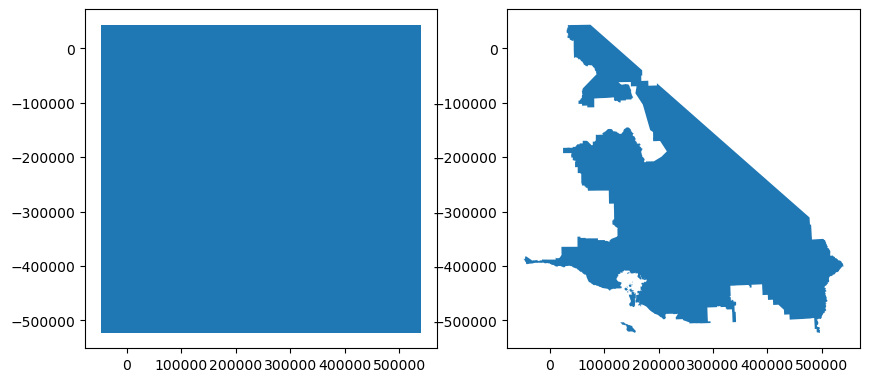

In [ ]:
# plot box of sce & territory
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sce_territory_box.plot(ax=axes[0])
sce_territory.plot(ax=axes[1])

In [12]:
# load buildings
path = "../../../../capstone/electrigrid/data/buildings/w120_n35_w115_n30.parquet"
buildings = gpd.read_parquet(path)

In [17]:
buildings.shape

(9503685, 7)

In [18]:
buildings.crs

<Geographic 2D CRS: OGC:CRS84>
Name: WGS 84 (CRS84)
Axis Info [ellipsoidal]:
- Lon[east]: Geodetic longitude (degree)
- Lat[north]: Geodetic latitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [14]:
# Convert buildings crs
buildings = buildings.to_crs(epsg=3310)

In [15]:
# reduce buildings to sce territory box
buildings_box = buildings.sjoin(sce_territory_box[['geometry']], how='inner', predicate='within').drop(labels=['index_right'], axis=1)

,source,id,height,var,region,bbox,geometry
4573022,ms,UnitedStates_023012311_832219,2.387687,0.517549,USA,"{'xmin': -118.1729984496768, 'ymin': 33.936795...","POLYGON ((168919.301 -451531.981, 168921.215 -..."
4573023,ms,UnitedStates_023012311_307170,0.439230,0.160512,USA,"{'xmin': -118.17212533361956, 'ymin': 33.93705...","POLYGON ((168991.534 -451497.439, 168997.341 -..."
4607921,ms,UnitedStates_023012311_1217650,2.483286,0.699443,USA,"{'xmin': -118.1722285390422, 'ymin': 33.937674...","POLYGON ((168990.369 -451450.755, 168980.975 -..."
4607922,ms,UnitedStates_023012311_171473,4.941268,1.518147,USA,"{'xmin': -118.17301420371393, 'ymin': 33.93831...","POLYGON ((168916.481 -451359.233, 168926.537 -..."
4607923,ms,UnitedStates_023012311_981135,5.603391,0.418036,USA,"{'xmin': -118.1727764737718, 'ymin': 33.938924...","POLYGON ((168943.109 -451312.981, 168927.656 -..."


In [ ]:
# reduce buildings box to sce territory
buildings_sce = buildings_box.sjoin(sce_territory[['geometry']], how='inner', predicate='within').drop(labels=['index_right'], axis=1)

# Link data

In [49]:
# Join buildings to nearest feeder section
data_linked = gpd.sjoin_nearest(buildings_sce, sce_segments_table, how='left', distance_col='dist_to_line_m')

In [ ]:
# reduce linked data to one circuit for test plotting
test_buildings = data_linked[data_linked['circuit_name'] == 'Parafine']

<Axes: >

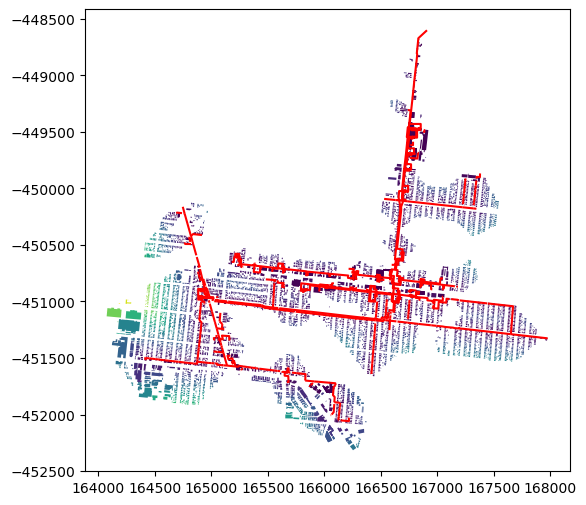

In [43]:
fig, ax = plt.subplots(figsize=(10,6))
test_circuit.plot(ax=ax, color='red')
test_buildings.plot(ax=ax, column='dist_to_line_m')

In [44]:
data_linked.head()

,source,id,height,var,region,bbox,geometry,index_right,download_link_microgrid,changed_date,lgp_flag,most_limiting_factor,circuit_name,section_id,node_id,phase,circuit_voltage_x,substation_name,substation_voltage,system_name,ica_overall_load,ica_overall_pv_op_flex,ica_overall_pv,uniform_generation_op_flex,uniform_generation,note,download_link,disclaimer,objectid,Shape__Length,circuit_id,circuit_voltage_y,percent_15_cap,res_pct,com_pct,agr_pct,other_pct,ind_pct,sub_name,subst_id,note_sub,layer_identifier,sys_name,existing_gen,queued_gen,total_gen,projected_load,penetration_level,max_remain_cap,agr_total,com_total,ind_total,res_total,other_total,OBJECTID,dist_to_line_m
730278,osm,1153621624,0.330804,0.015087,USA,"{'xmin': -115.21040229999998, 'ymin': 33.48954...","POLYGON ((445155.899 -491522.790, 445159.353 -...",287750,https://Microgrid.sce.com/icafiledownload/mode...,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,2124,31821.640958
730279,osm,1178216366,0.141396,0.000986,USA,"{'xmin': -115.210088, 'ymin': 33.4901858, 'xma...","POLYGON ((445181.522 -491450.833, 445182.970 -...",287750,https://Microgrid.sce.com/icafiledownload/mode...,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,2124,31778.066523
730280,ms,UnitedStates_023013302_1517,2.516834,0.402308,USA,"{'xmin': -115.05713599999999, 'ymin': 33.60176...","POLYGON ((458739.838 -478367.717, 458746.671 -...",287750,https://Microgrid.sce.com/icafiledownload/mode...,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,2124,33895.750019
730281,ms,UnitedStates_023013302_1615,0.527584,0.128212,USA,"{'xmin': -115.069469, 'ymin': 33.62861, 'xmax'...","POLYGON ((457646.930 -475445.494, 457647.290 -...",287750,https://Microgrid.sce.com/icafiledownload/mode...,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,2124,31607.059731
730282,ms,UnitedStates_023013302_2446,0.225701,0.013953,USA,"{'xmin': -115.07126099999999, 'ymin': 33.62947...","POLYGON ((457313.268 -475359.942, 457279.530 -...",287750,https://Microgrid.sce.com/icafiledownload/mode...,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,https://drpep.sce.com/icafiledownload/models/w...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,2124,31434.452348


To prepare this GeoDataFrame for export, drop some unneccessary columns.

In [50]:
data_linked = data_linked.drop(['download_link_microgrid', 'download_link', 'OBJECTID'], axis='columns')

In [51]:
# Confirm dropped columns
data_linked.head()

,source,id,height,var,region,bbox,geometry,index_right,changed_date,lgp_flag,most_limiting_factor,circuit_name,section_id,node_id,phase,circuit_voltage_x,substation_name,substation_voltage,system_name,ica_overall_load,ica_overall_pv_op_flex,ica_overall_pv,uniform_generation_op_flex,uniform_generation,note,disclaimer,objectid,Shape__Length,circuit_id,circuit_voltage_y,percent_15_cap,res_pct,com_pct,agr_pct,other_pct,ind_pct,sub_name,subst_id,note_sub,layer_identifier,sys_name,existing_gen,queued_gen,total_gen,projected_load,penetration_level,max_remain_cap,agr_total,com_total,ind_total,res_total,other_total,dist_to_line_m
730278,osm,1153621624,0.330804,0.015087,USA,"{'xmin': -115.21040229999998, 'ymin': 33.48954...","POLYGON ((445155.899 -491522.790, 445159.353 -...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,31821.640958
730279,osm,1178216366,0.141396,0.000986,USA,"{'xmin': -115.210088, 'ymin': 33.4901858, 'xma...","POLYGON ((445181.522 -491450.833, 445182.970 -...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,31778.066523
730280,ms,UnitedStates_023013302_1517,2.516834,0.402308,USA,"{'xmin': -115.05713599999999, 'ymin': 33.60176...","POLYGON ((458739.838 -478367.717, 458746.671 -...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,33895.750019
730281,ms,UnitedStates_023013302_1615,0.527584,0.128212,USA,"{'xmin': -115.069469, 'ymin': 33.62861, 'xmax'...","POLYGON ((457646.930 -475445.494, 457647.290 -...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,31607.059731
730282,ms,UnitedStates_023013302_2446,0.225701,0.013953,USA,"{'xmin': -115.07126099999999, 'ymin': 33.62947...","POLYGON ((457313.268 -475359.942, 457279.530 -...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,NaN,NaN,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,31434.452348


In [ ]:
# write linked data to geopkg (~21m)
# data_linked.to_file("buildings_sce.gpkg", driver='GPKG')

In [ ]:
# read gpkg (~13m)
# buildings_gpkg = gpd.read_file('buildings_sce.gpkg')

In [54]:
buildings_gpkg.head()

,source,id,height,var,region,bbox,index_right,changed_date,lgp_flag,most_limiting_factor,circuit_name,section_id,node_id,phase,circuit_voltage_x,substation_name,substation_voltage,system_name,ica_overall_load,ica_overall_pv_op_flex,ica_overall_pv,uniform_generation_op_flex,uniform_generation,note,disclaimer,objectid,Shape__Length,circuit_id,circuit_voltage_y,percent_15_cap,res_pct,com_pct,agr_pct,other_pct,ind_pct,sub_name,subst_id,note_sub,layer_identifier,sys_name,existing_gen,queued_gen,total_gen,projected_load,penetration_level,max_remain_cap,agr_total,com_total,ind_total,res_total,other_total,dist_to_line_m,geometry
0,osm,1153621624,0.330804,0.015087,USA,"{""xmin"": -115.21040229999998, ""ymin"": 33.48954...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,None,None,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,31821.640958,"POLYGON ((445155.899 -491522.790, 445159.353 -..."
1,osm,1178216366,0.141396,0.000986,USA,"{""xmin"": -115.210088, ""ymin"": 33.4901858, ""xma...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,None,None,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,31778.066523,"POLYGON ((445181.522 -491450.833, 445182.970 -..."
2,ms,UnitedStates_023013302_1517,2.516834,0.402308,USA,"{""xmin"": -115.05713599999999, ""ymin"": 33.60176...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,None,None,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,33895.750019,"POLYGON ((458739.838 -478367.717, 458746.671 -..."
3,ms,UnitedStates_023013302_1615,0.527584,0.128212,USA,"{""xmin"": -115.069469, ""ymin"": 33.62861, ""xmax""...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,None,None,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,31607.059731,"POLYGON ((457646.930 -475445.494, 457647.290 -..."
4,ms,UnitedStates_023013302_2446,0.225701,0.013953,USA,"{""xmin"": -115.07126099999999, ""ymin"": 33.62947...",287750,02/08/2025,No,NA,Chuckawalla,85755857,40563069,3,12,Eagle Mountain,66/12 kV,Eagle Mountain 220/220 System,NaN,None,NaN,None,NaN,This is a potentially constrained circuit.Load...,N,287751,487.180353,2157482.0,12.0,0.07,43.59,12.82,0.0,43.59,0.0,Eagle Mountain,None,None,ESRI_CIRCUIT_3_T_DRP,Eagle Mountain 220/220 System,0.107,0.0,0.107,1.15,9.29,9.89,0.0,5.0,0.0,17.0,17.0,31434.452348,"POLYGON ((457313.268 -475359.942, 457279.530 -..."
